# Úkol č. 1 - předzpracování dat a binární klasifikace

* Termíny jsou uvedeny na [courses.fit.cvut.cz/BI-ML1/homeworks/index.html](https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html).
* Pokud odevzdáte úkol po prvním termínu ale před nejzazším termínem, budete penalizování -12 body, pozdější odevzdání je bez bodu.
* V rámci tohoto úkolu se musíte vypořádat s klasifikační úlohou s příznaky různých typů a s chybějícími hodnotami.
* Před tím, než na nich postavíte predikční model, je třeba je nějakým způsobem převést do číselné reprezentace.
    
> **Úkoly jsou zadány tak, aby Vám daly prostor pro invenci. Vymyslet _jak přesně_ budete úkol řešit, je důležitou součástí zadání a originalita či nápaditost bude také hodnocena!**

Využívejte buňky typu `Markdown` k vysvětlování Vašeho postupu. Za nepřehlednost budeme strhávat body.

## Zdroj dat

Budeme se zabývat predikcí přežití pasažérů Titaniku.
K dispozici máte trénovací data v souboru `data.csv` a data na vyhodnocení v souboru `evaluation.csv`.

#### Seznam příznaků:
* survived - zda pasažér přežil, 0 = Ne, 1 = Ano; **vysvětlovaná proměnná**, kterou chcete predikovat
* pclass - Třída lodního lístku, 1 = první, 2 = druhá, 3 = třetí
* name - jméno
* sex - pohlaví
* age - věk v letech
* sibsp	- počet sourozenců / manželů, manželek na palubě
* parch - počet rodičů / dětí na palubě
* ticket - číslo lodního lístku
* fare - cena lodního lístku
* cabin	- číslo kajuty
* embarked	- místo nalodění, C = Cherbourg, Q = Queenstown, S = Southampton
* home.dest - Bydliště/Cíl

## Pokyny k vypracování

**Body zadání**, za jejichž (poctivé) vypracování získáte **25 bodů**: 
  * V notebooku načtěte data ze souboru `data.csv`. Vhodným způsobem si je rozdělte na podmnožiny, které Vám poslouží pro trénování (trénovací), porovnávání modelů (validační) a následnou predikci výkonnosti finálního modelu (testovací).
    
  * Proveďte základní předzpracování dat:
    * Projděte si jednotlivé příznaky a transformujte je do vhodné podoby pro použití ve vybraném klasifikačním modelu.
    * Podle potřeby si můžete vytvářet nové příznaky (na základě existujících), například tedy můžete vytvořit příznak měřící délku jména atp.
    * Některé příznaky můžete také úplně zahodit.
    * Nějakým způsobem (klidně triviálním) se vypořádejte s chybějícími hodnotami. Není potřeba používat sofistikované metody. _Hlavně pozor na metodické chyby!_
    * Můžete využívat i vizualizace a vše stručně ale náležitě komentujte.

  
  * Na připravená data postupně aplikujte **rozhodovací strom** a **metodu nejbližších sousedů**, přičemž pro každý z těchto modelů:
    * Okomentujte vhodnost daného modelu pro daný typ úlohy.
    * Vyberte si hlavní hyperparametry k ladění a najděte jejich nejlepší hodnoty.
    * Pro model s nejlepšími hodnotami hyperparametrů spočtěte (na validační množině) F1 skóre, nakreslete ROC křivku a určete AUC. _Pozor na metodické chyby!_
    * Získané výsledky vždy řádně okomentujte.

        
  * Ze všech zkoušených možností v předchozím kroku vyberte finální model (jednoznačně popište o který konkrétně jde) a správně odhadněte, jakou **přesnost** můžete očekávat na nových datech, která jste doposud neměli k dispozici. _Pozor na metodické chyby!_
    
  * Nakonec načtěte vyhodnocovací data ze souboru `evaluation.csv`. Pomocí finálního modelu napočítejte predikce pro tyto data (vysvětlovaná proměnná v nich již není). Vytvořte soubor `results.csv`, ve kterém získané predikce uložíte do sloupce **survived** a identifikátory do sloupce **ID** (dodržte názvy sloupců!). Tento soubor též odevzdejte (uložte do repozitáře vedle notebooku).

      * Snažte se vše udělat tak, aby přesnost odevzdaných predikcí na vyhodocovacím datasetu byla alespoň **75%**. Pokud bude menší, přijdete o **3 body**.
      * Ukázka, jak by mělo vypadat prvních několik řádků souboru `results.csv` (obecně s jinými hodnotami survived):
  
```
ID,survived
1000,0
1001,1
...
```

## Poznámky k odevzdání

  * Řiďte se pokyny ze stránky https://courses.fit.cvut.cz/BI-ML1/homeworks/index.html.
  * Vytvořte i csv soubor `results.csv` s predikcemi a uložte ho v rámci projektu vedle ipython notebooku.

---


# Vypracování úkolu

Nejprve naimportuji balíčky, které se budou v celém úkolu používat (některé další jsou pak naimportovány ještě dodatečně přímo na příslušných místech v úkolu).

In [1]:
import math
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline 

### Načtení dat a jejich rozdělení na trénovací, validační a testovací množinu

In [2]:
# Načtu data z CSV souboru data.csv
df = pd.read_csv("data.csv")

# Zobrazím hlavičku
display(df.shape)
df.head()

(1000, 13)

,ID,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest
0,0,0,2,"Baimbrigge, Mr. Charles Robert",male,23.0,0,0,C.A. 31030,10.5000,NaN,S,Guernsey
1,1,0,3,"Aronsson, Mr. Ernst Axel Algot",male,24.0,0,0,349911,7.7750,NaN,S,"Sweden Joliet, IL"
2,2,0,3,"Novel, Mr. Mansouer",male,28.5,0,0,2697,7.2292,NaN,C,NaN
3,3,0,3,"Osen, Mr. Olaf Elon",male,16.0,0,0,7534,9.2167,NaN,S,NaN
4,4,1,2,"Navratil, Master. Michel M",male,3.0,1,1,230080,26.0000,F2,S,"Nice, France"


Vysvětlovanou proměnnou, kterou chceme predikovat je **survived**. Dataset tedy rozdělím na cílovou proměnnou, kterou chceme predikovat (y), a na matici příznaků, ze které budu predikovat (X).

In [3]:
Xdata = df.drop("survived", axis = 1)
ydata = df.survived

Dále si data rozdělím na trénovací, validační  a testovací množinu tak, aby 60 % dat bylo v množině trénovací, 20 % ve validační a 20% v testovací (data jsou rozdělována náhodně).

In [4]:
rd_seed = 333 
from sklearn.model_selection import train_test_split

# Provedu nejprve rozdělení na 2 množiny (trénovací a "zbytek") v poměru 3:2
Xtrain, Xrest, ytrain, yrest = train_test_split(Xdata, ydata, test_size=0.4, random_state=rd_seed) 
print(f"Xtrain: {Xtrain.shape}")
print(f"ytrain: {ytrain.shape}")
print(f"Xrest: {Xrest.shape}")
print(f"yrest: {yrest.shape}")

# A následně ještě rozdělím množinu "zbytek" na validační a testovací (v poměru 1:1)
Xtest, Xval, ytest, yval = train_test_split(
    Xrest, yrest, test_size=0.5, random_state=rd_seed
)
print(f"Xtest: {Xtest.shape}")
print(f"ytest: {ytest.shape}")
print(f"Xval: {Xval.shape}")
print(f"yval: {yval.shape}")

Xtrain: (600, 12)
ytrain: (600,)
Xrest: (400, 12)
yrest: (400,)
Xtest: (200, 12)
ytest: (200,)
Xval: (200, 12)
yval: (200,)


### Příprava dat před použitím modelu

In [5]:
# Zobrazím základní informace o dataframu
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   survived   1000 non-null   int64  
 2   pclass     1000 non-null   int64  
 3   name       1000 non-null   object 
 4   sex        1000 non-null   object 
 5   age        796 non-null    float64
 6   sibsp      1000 non-null   int64  
 7   parch      1000 non-null   int64  
 8   ticket     1000 non-null   object 
 9   fare       1000 non-null   float64
 10  cabin      225 non-null    object 
 11  embarked   1000 non-null   object 
 12  home.dest  573 non-null    object 
dtypes: float64(2), int64(5), object(6)
memory usage: 101.7+ KB


None

Je vidět, že pro některé příznaky jsou v datasetu chybějící hodnoty a některé příznaky jsou nenumerické.

In [6]:
# Zobrazím počet unikátních hodnot pro každý z příznaků
display(df.nunique())

ID           1000
survived        2
pclass          3
name          998
sex             2
age            93
sibsp           7
parch           8
ticket        747
fare          260
cabin         155
embarked        3
home.dest     308
dtype: int64

In [7]:
# Zobrazím počet chybějících hodnot v dataframu pro každý z příznaků
display(df.isnull().sum(axis=0))

ID             0
survived       0
pclass         0
name           0
sex            0
age          204
sibsp          0
parch          0
ticket         0
fare           0
cabin        775
embarked       0
home.dest    427
dtype: int64

V datasetu jsou u příznaků age, cabin a home.dest chybějící hodnoty.

Některé příznaky jsou jiného typu než float nebo integer, jsou typu object - tedy nenumerické (příznaky name, sex, ticket, cabin, embarked, home.dest).
Implementace rozhodovacího stromu a kNN v `sklearn` si neumí poradit s nenumerickými příznaky, musím proto nahradit stringy nějakými číselnými kódy. Žádný z těchto příznaků není ordinální, nechám to `pandas` udělat automaticky

In [8]:
# Převedu textové příznaky na kategorické
Xtrain[Xtrain.select_dtypes(['object']).columns] =Xtrain.select_dtypes(['object']).astype('category')
Xval[Xval.select_dtypes(['object']).columns] =Xval.select_dtypes(['object']).astype('category')
Xtest[Xtest.select_dtypes(['object']).columns] =Xtest.select_dtypes(['object']).astype('category')

# A nahradím kategorické proměnné jejich kódy
Xtrain[Xtrain.select_dtypes(['category']).columns] = Xtrain.select_dtypes(['category']).apply(lambda x: x.cat.codes)
Xval[Xval.select_dtypes(['category']).columns] = Xval.select_dtypes(['category']).apply(lambda x: x.cat.codes)
Xtest[Xtest.select_dtypes(['category']).columns] = Xtest.select_dtypes(['category']).apply(lambda x: x.cat.codes)

Příznaků je v původním datasetu 13, ale některé (podle mého názoru) nemají velký význam pro predikci přežití.  Rozhodla jsem se proto vynechat příznaky ID, name, dále ticket (má velké množství unikátních hodnot v datasetu), cabin (hodně unikátních hodnot a okolo tří čtvrtin hodnot pro příznak cabin chybí) a home.dest (opět velké množství unikátních hodnot, chybějících hodnot a nejednotného zápisu hodnot v tomto příznaku).

In [9]:
# Odstraním zbytečné sloupce
Xtrain = Xtrain.drop(columns=["ID", "name", "ticket", "cabin", "home.dest"])
Xval = Xval.drop(columns=["ID", "name", "ticket", "cabin", "home.dest"])
Xtest = Xtest.drop(columns=["ID", "name", "ticket", "cabin", "home.dest"])

Dále je potřeba se postarat o chybějící hodnoty zbývajících příznaků. Chybějící hodnoty příznaku age nahradím průměrem hodnot věku z trénovací množiny dat (bude to lepší nahrazení, než pokud by se chybějící hodnoty nahradily -1).

In [10]:
Xtrain, Xval, Xtest
# Spočítám průměrný věk v trénovací množině
mean_age = Xtrain['age'].mean()
display(mean_age)

# Nahradím chybějící hodnoty age v trénovací, validační a testovací množině
Xtrain['age'] = Xtrain['age'].fillna(mean_age)
Xval['age'] = Xval['age'].fillna(mean_age)
Xtest['age'] = Xtest['age'].fillna(mean_age)

29.578224101479915

Pro ostatní chybějící hodnoty použiji nahrazení -1.

In [11]:
Xtrain = Xtrain.fillna(-1)
Xval = Xval.fillna(-1)
Xtest = Xtest.fillna(-1)

In [12]:
Xtrain.head()

,pclass,sex,age,sibsp,parch,fare,embarked
468,3,0,29.578224,0,0,7.7500,1
314,1,0,35.000000,1,0,90.0000,2
881,2,1,32.000000,0,0,10.5000,2
705,3,1,26.000000,1,0,7.8542,2
231,3,1,29.578224,0,0,7.7500,1


## Rozhodovací strom

Tato úloha je úlohou binární klasifikace, a tak je rozhodovací strom jednou z možností sestavení vhodného modelu pro predikci přežití pasažérů Titanicu. Výhodou rozhodovacího stromu je jeho přehlednost, kdy lze dohledat, podle jakého příznaku a jak se strom rozhodoval - je snadno interpretovatelný. Pro jeho použití není nutné data normalizovat, jeho trénování je rychlé, ale je třeba dbát na to, aby nedošlo k přeučení rozhodovacího stromu.

In [13]:
from sklearn.tree import DecisionTreeClassifier

### Ladění hyperparametrů

Jako hyperparamtery, které budu ladit, jsem vybrala maximální hloubku stromu (v rozmezí 1-30) a kritérium pro měření kvality rozdělení, kde se použije buď entropie nebo Gini Index.

In [14]:
from sklearn.model_selection import ParameterGrid
param_grid = {
    'max_depth': range(1,30), 
    'criterion': ['entropy', 'gini']
}
param_comb = ParameterGrid(param_grid)

Naučím model pro všechny hyperparametry pomocí metody `.fit()` a naměřím přesnost na trénovacích a validačních datech.

In [15]:
import sklearn.metrics as metrics
val_acc = []
train_acc = []
for params in param_comb:
    dt = DecisionTreeClassifier(max_depth=params['max_depth'], criterion=params['criterion'], random_state = 42)
    dt.fit(Xtrain, ytrain)
    train_acc.append(metrics.accuracy_score(ytrain, dt.predict(Xtrain)))
    val_acc.append(metrics.accuracy_score(yval, dt.predict(Xval)))

Provedu grafické zobrazení přesnosti na trénovací a validační množině.

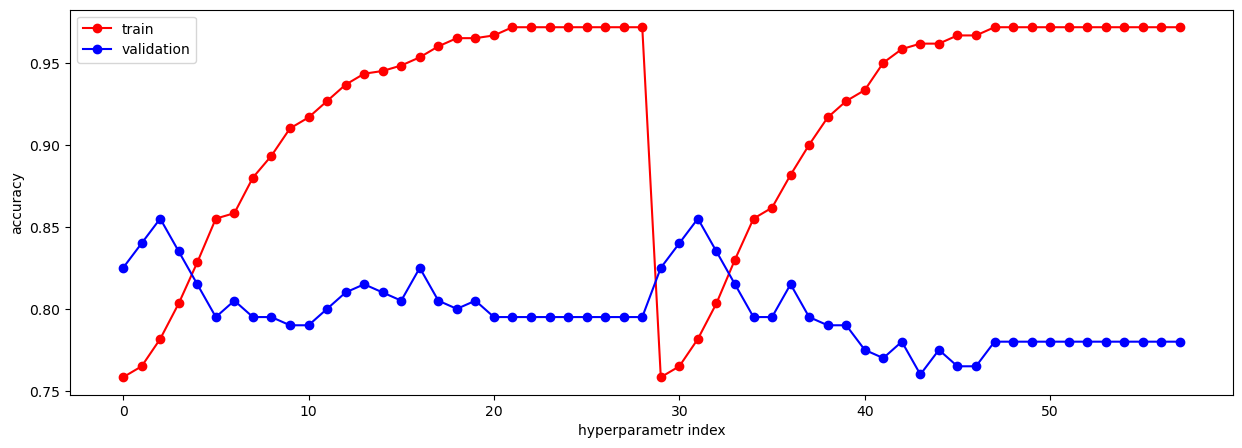

In [16]:
plt.figure(figsize=(15,5))
plt.plot(train_acc,'or-')
plt.plot(val_acc,'ob-')
plt.xlabel('hyperparametr index')
plt.ylabel('accuracy')
plt.legend(['train', 'validation'])

Lze vidět, že na trénovací množině se přesnost s rostoucí hloubkou stromu dostane až na hodnotu 1 (stromy jsou pak stejné), na validační množině přesnost naopak klesá - strom je přeučený. Musíme proto zvolit nejvhodnější kombinaci hyperparametrů (hledám tedy nejvyšší hodnotu přesnosti na validačních datech).

In [17]:
# Najdu nejvhodnější parametry
best_params = param_comb[np.argmax(val_acc)]
print('best params', best_params)

best params {'max_depth': 3, 'criterion': 'entropy'}


Jako nejlepší kombinace hyperparametrů byla určena maximální hloubka stromu 3 a entropie pro výpočet informačního zisku (měření kvality rozdělení).
Nyní tyto hyperparametry použiji pro naučení rozhodovacího stromu.

In [18]:
# Natrénování rozhodovacího stromu s nejlepšími hyperparametry
dt = DecisionTreeClassifier(max_depth=best_params['max_depth'], criterion=best_params['criterion'], random_state=42)
dt.fit(Xtrain, ytrain)

# Vypsání přesnosti na trénovací a validační množině
print('accuracy score (train): {0:.4f}'.format(metrics.accuracy_score(ytrain, dt.predict(Xtrain))))
print('accuracy score (validation): {0:.4f}'.format(metrics.accuracy_score(yval, dt.predict(Xval))))

accuracy score (train): 0.7817
accuracy score (validation): 0.8550


Dále spočítám F1 skóre na validační množině.

In [19]:
# Vytvořím matici záměn (jen pro ilustraci)
cfDT = metrics.confusion_matrix(yval, dt.predict(Xval))

print("Rozhodovací strom")
print(cfDT)
print(f'Accuracy score (val): {metrics.accuracy_score(yval, dt.predict(Xval)):.4f}')

# Spočítám F1 score
print(f'F1 score (val): {metrics.f1_score(yval, dt.predict(Xval)):.4f}')

Rozhodovací strom
[[121  16]
 [ 13  50]]
Accuracy score (val): 0.8550
F1 score (val): 0.7752


F1 skóre (měřeno na validační množině) vyšlo 0.7752. Čím více se F skóre blíží 1, tím model dosahuje lepší rovnováhy mezi přesností a senzitivitou. Accuracy - přesnost vychází 85,5 %. Tyto hodnoty budou použity k porovnání tohoto vybraného rozhodovacího stromu a kNN s vybranými nejlepšími hyperparametry.

Dále vykreslím ROC křivku a spočítám plochu pod ní (AUC)

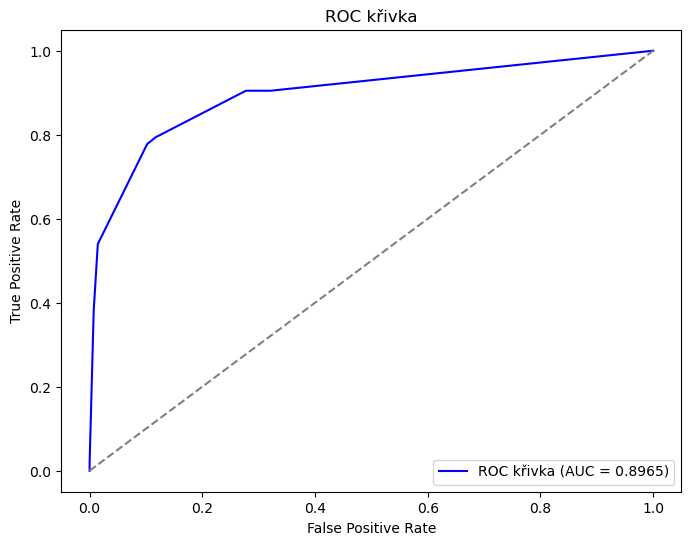

In [20]:
y_pred_proba = dt.predict_proba(Xval)

fpr, tpr, thresholds = metrics.roc_curve(yval, y_pred_proba[:,1])

# Spočítám AUC
AUC_dt = metrics.roc_auc_score(yval, y_pred_proba[:,1])

# Vykreslím ROC křivku
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC křivka (AUC = {AUC_dt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC křivka')
plt.legend(loc='lower right')
plt.show()

ROC křivka dobrého modelu strmě stoupá k levému hornímu rohu a poté již jen velmi pomalu stoupá k pravému hornímu rohu. ROC křivka vykreslená pro rozhodovací strom s vybranými nejlepšími hyperparametry poměrně splňuje tyto charakteristiky. Plocha pod touto křivkou (AUC) vyšla 0.8965, což značí, že model má poměrně dobrou schopnost rozlišovat mezi třídami.

## Metoda nejbližších sousedů kNN

Dalším modelem je metoda nejbližších sousedů, která je na rozdíl od rozhodovacího stromu náročnější na přípravu dat a také je citlivá na typy jednotlivých příznaků. Ale pro úlohu binární klasifikace se také dá vhodně využít. Provedu její natrénování, ladění hyperparametrů a porovnám s rozhodovacím stromem.

In [21]:
# Naimportuji KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
Xtrain_knn = Xtrain
Xval_knn = Xval
Xtest_knn = Xtest

# Nafituji na trénovací množině a změřím accuracy na validační množině
knn = KNeighborsClassifier()
knn.fit(Xtrain_knn, ytrain)
print(f"Validation accuracy: {metrics.accuracy_score(yval, knn.predict(Xval_knn)):0.4f}")

Validation accuracy: 0.6700


Přesnost (accuracy) na validační množině je poměrně nízká, stojí za to vyzkoušet normalizaci dat.

### Normalizace

Jako první vyzkouším min-max normalizaci příznaků, která normalizuje každý příznak do intervalu <0,1>.

In [22]:
Xtrain_knn, Xval_knn, Xtest_knn, ytrain, yval, ytest

from sklearn.preprocessing import MinMaxScaler

# Min-max scaler nafituji na trénovacích datech
scaler = MinMaxScaler()
Xtrain_scaled1 = scaler.fit_transform(Xtrain_knn)

# Následně stejnou transformaci aplikuji i na validační data
Xval_scaled1 = scaler.transform(Xval_knn)

# Natrénuji model na transformovaných datech
knn = KNeighborsClassifier()
knn.fit(Xtrain_scaled1, ytrain)

print(f"Validation accuracy of normalized model: {knn.score(Xval_scaled1, yval):0.4f}")

Validation accuracy of normalized model: 0.8400


Přesnost na validační množině se zvýšila, normalizace tedy byla ku prospěchu, ještě vyzkouším standardizaci.

In [23]:
Xtrain_knn, Xval_knn, Xtest_knn, ytrain, yval, ytest
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xtrain_scaled2 = scaler.fit_transform(Xtrain_knn)
Xval_scaled2 = scaler.transform(Xval_knn)
knn = KNeighborsClassifier()
knn.fit(Xtrain_scaled2, ytrain)

print(f"Validation accuracy of normalized model: {knn.score(Xval_scaled2, yval):0.4f}")

Validation accuracy of normalized model: 0.8600


Přesnost na validační množině se zvýšila i oproti min-max normalizaci, tedy vyberu tuto normalizaci jako vhodnou pro dataset.

### Ladění hyperparametrů

Jako hyperparamtery, které budu ladit, jsem vybrala počet sousedů (v rozmezí 3-15), váhu sousedů a parametr p pro výpočet vzdálenosti. Opět jako u rozhodovacího stromu naučím model pro všechny hyperparametry pomocí metody `.fit()` a naměřím přesnost na trénovacích a validačních datech (používám data normalizovaná - po použití standardizace).

In [24]:
param_grid2 = {
    'n_neighbors': range(3,15),
    'weights': ['uniform', 'distance'],
    'p' : [1, 2]
}
param_comb2 = ParameterGrid(param_grid2)

val_acc_knn = []
train_acc_knn = []
for params in param_comb2:
    knn = KNeighborsClassifier(n_neighbors = params['n_neighbors'], weights = params['weights'], p = params['p'])
    knn.fit(Xtrain_scaled2, ytrain)
    val_acc_knn.append(knn.score(Xval_scaled2, yval))
    train_acc_knn.append(knn.score(Xtrain_scaled2, ytrain))

Udělám grafické zobrazení přesnosti na trénovací a validační množině pro zkoušené hyperparametry.

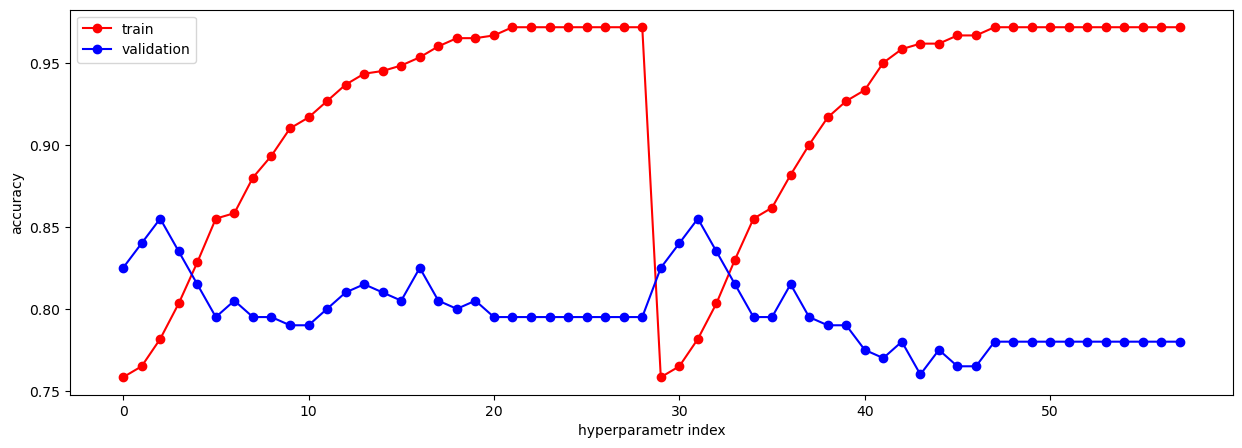

In [25]:
plt.figure(figsize=(15,5))
plt.plot(train_acc,'or-') 
plt.plot(val_acc,'ob-')
plt.xlabel('hyperparametr index')
plt.ylabel('accuracy')
plt.legend(['train', 'validation'])
plt.show()

Nyní najdu nejvhodnější hyperparametry.

In [26]:
best_params2 = param_comb2[np.argmax(val_acc_knn)]
print('best params', best_params2)

best params {'weights': 'uniform', 'p': 1, 'n_neighbors': 10}


Jako nejlepší hyperparamtery vyšel počet sousedů k = 10, kteří budou mít stejnou váhu a pro výpočet vzdálenosti má být použita manhattanská metrika (protože parametr p vyšel roven 1). Nyní tyto hyperparametry použiji pro natrénování metody nejbližších sousedů.

In [27]:
knn = KNeighborsClassifier(n_neighbors=best_params2['n_neighbors'], weights=best_params2['weights'], p=best_params2['p'])
knn.fit(Xtrain_scaled2, ytrain)
print('accuracy score (train): {0:.4f}'.format(metrics.accuracy_score(ytrain, knn.predict(Xtrain_scaled2))))
print('accuracy score (validation): {0:.4f}'.format(metrics.accuracy_score(yval, knn.predict(Xval_scaled2))))

accuracy score (train): 0.8167
accuracy score (validation): 0.8650


Dále opět spočítám F1 score, vykreslím ROC křivku a spočtu AUC

In [28]:
# Vytvořím matici záměn
cfKNN = metrics.confusion_matrix(yval, knn.predict(Xval_scaled2))
print("kNN")
print(cfKNN)
print(f'Accuracy score (val): {metrics.accuracy_score(yval, knn.predict(Xval_scaled2)):.4f}')

# Spočítám F1 skóre
print(f'F1 score (val): {metrics.f1_score(yval, knn.predict(Xval_scaled2)):.4f}')

kNN
[[131   6]
 [ 21  42]]
Accuracy score (val): 0.8650
F1 score (val): 0.7568


F1 skóre (měřeno na validační množině) vyšlo 0.7568, accuracy - přesnost vychází 86,5 %. Tyto hodnoty budou použity k porovnání tohoto vybraného modelu kNN s vybranými nejlepšími hyperparametry s rozhodovacím stromem s nejlepšími hyperparametry.

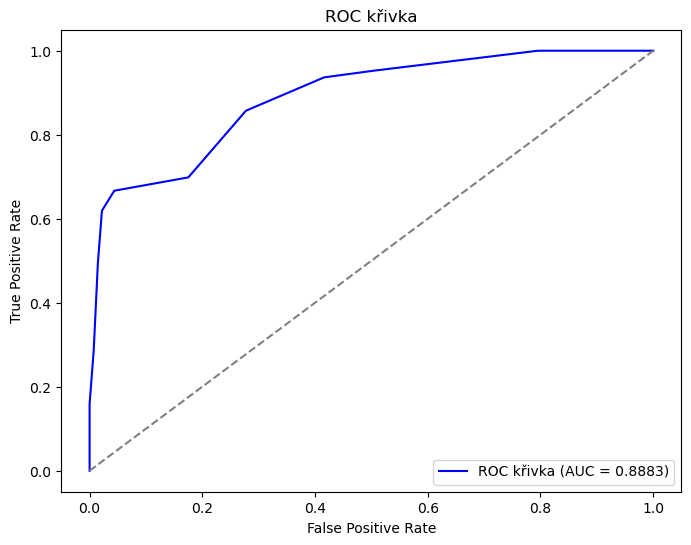

In [29]:
y_pred_proba2 = knn.predict_proba(Xval_scaled2)
fpr, tpr, thresholds = metrics.roc_curve(yval, y_pred_proba2[:,1])

AUC_knn = metrics.roc_auc_score(yval, y_pred_proba2[:,1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='b', label=f'ROC křivka (AUC = {AUC_knn:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC křivka')
plt.legend(loc='lower right')
plt.show()

ROC křivka vykreslená pro metodu nejbližších sousedů také stoupá poměrně strmě k levému hornímu rohu a poté již pozvolněji k pravému hornímu rohu. AUC v tomto případě vyšlo 0.8883.

## Výběr finálního modelu

Pro výběr vhodnějšího modelu si zobrazím důležité výsledky pro obě metody/oba modely s nejlepšími hyperparametry.


In [30]:
print("accuracy score (validation)")
print('DT: {0:.4f}'.format(metrics.accuracy_score(yval, dt.predict(Xval))))
print('kNN: {0:.4f}'.format(metrics.accuracy_score(yval, knn.predict(Xval_scaled2))))

print("---------------")

print("F1 score")
print(f'DT: {metrics.f1_score(yval, dt.predict(Xval)):.4f}')
print(f'kNN: {metrics.f1_score(yval, knn.predict(Xval_scaled2)):.4f}')

print("---------------")

print("AUC")
print('DT: {0:.4f}'.format(metrics.roc_auc_score(yval, y_pred_proba[:,1])))
print('kNN: {0:.4f}'.format(metrics.roc_auc_score(yval, y_pred_proba2[:,1])))

accuracy score (validation)
DT: 0.8550
kNN: 0.8650
---------------
F1 score
DT: 0.7752
kNN: 0.7568
---------------
AUC
DT: 0.8965
kNN: 0.8883


Rozhodovací strom s danými hyperparametry (vybranými výše - maximální hloubka stromu 3 a entropie pro výpočet informačního zisku) vychází ve dvou z těchto tří metrik lépe než metoda nejbližších sousedů (s vybranými nejlepšími hyperparamtery opět viz výše - počet sousedů je 10, metrika manhattanská, váhy sousedů uniformní), zvolím proto jako nejlepší model pro tuto úlohu rozhodovací strom s uvedenými hyperparametry (max. hloubka stromu 3, entropie pro výpočet IG). Model rozhodovacího stromu se liší v accuracy na validační množině o 1 % oproti modelu kNN, accuracy ale může být ovlivněna nevyvážeností datasetu. Pro takové datasety je pak důležitější F skóre a AUC, ve kterých je rozhodovací strom lepší.

In [31]:
# Ilustrace vyváženosti datasetu (vypočtu poměr survived = 1 ku celkovému počtu pasažérů v datasetu)
df["survived"].sum()/1000

0.373

### Odhad přesnosti na nových datech

Jak se bude vybraný model chovat na nových datech odhadneme pomocí testovací množiny dat oddělené z datasetu na začátku, kterou model doposud neviděl. Přesnost změřená na testovacích datech je odhadem přesnosti (chyby) modelu.

In [32]:
print(f'Accuracy score (test): {metrics.accuracy_score(ytest, dt.predict(Xtest)):.4f}')

Accuracy score (test): 0.8450


Přesnost na nových datech lze očekávat 84,5 %.

## Predikce pro vyhodnocovací data

In [33]:
data_evaluation = pd.read_csv("evaluation.csv")
data_evaluation_dt = data_evaluation
data_evaluation_dt.head()

,ID,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest
0,1000,2,"Pengelly, Mr. Frederick William",male,19.0,0,0,28665,10.5,NaN,S,"Gunnislake, England / Butte, MT"
1,1001,2,"Beane, Mr. Edward",male,32.0,1,0,2908,26.0,NaN,S,"Norwich / New York, NY"
2,1002,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,NaN
3,1003,2,"Herman, Mrs. Samuel (Jane Laver)",female,48.0,1,2,220845,65.0,NaN,S,"Somerset / Bernardsville, NJ"
4,1004,1,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6,NaN,C,"Philadelphia, PA"


Ověřím si, zda mám stejné příznaky, jako v původním datasetu (kromě příznaku survived, který by měl ve vyhodnocovacích datech chybět, protože to je vysvětlovaná proměnná, kterou mám predikovat).

In [34]:
set(df.columns) - set(data_evaluation_dt.columns)

{'survived'}

Provedu s těmito daty stejné předzpracování, jaké jsem použila při předzpracování dat pro trénování vybraného modelu rozhodovacího stromu.

In [35]:
data_evaluation_dt[data_evaluation_dt.select_dtypes(['object']).columns] = data_evaluation_dt.select_dtypes(['object']).astype('category')
data_evaluation_dt[data_evaluation_dt.select_dtypes(['category']).columns] = data_evaluation_dt.select_dtypes(['category']).apply(lambda x: x.cat.codes)
data_evaluation_dt['age'] = data_evaluation_dt['age'].fillna(mean_age)
data_evaluation_dt = data_evaluation_dt.fillna(-1)
data_evaluation_dt = data_evaluation_dt.drop(columns=["ID", "name", "ticket", "cabin", "home.dest"])
data_evaluation_dt.head()


,pclass,sex,age,sibsp,parch,fare,embarked
0,2,1,19.000000,0,0,10.5,2
1,2,1,32.000000,1,0,26.0,2
2,3,1,60.500000,0,0,-1.0,2
3,2,0,48.000000,1,2,65.0,2
4,1,1,29.578224,0,0,39.6,0


In [36]:
y_prediction = dt.predict(data_evaluation_dt)

In [37]:
prediction = pd.DataFrame()

prediction['ID'] = data_evaluation['ID']
prediction['survived'] = y_prediction.tolist()

display(prediction)

,ID,survived
0,1000,0
1,1001,0
2,1002,0
3,1003,1
4,1004,0
...,...,...
304,1304,0
305,1305,0
306,1306,1
307,1307,1


In [38]:
prediction.to_csv('results.csv', index=False)